# 09 · RAG: corpus, fragmentos, índice y evaluación del retriever (T-11 y T-16, bloque M)

**Dónde:** `pipeline/src/rag/corpus.py` (corpus y chunking), `pipeline/src/rag/indexar.py` (embeddings + pgvector),
`api/_lib/rag.py` (consulta con umbral y fuentes), `pipeline/src/rag/evaluar.py` (métricas).
**Por qué:** el área de atención responde preguntas sobre tarifas y reglas del recibo; el RAG responde **solo** con
los documentos y dice cuándo no hay evidencia. **Cómo:** documentos → fragmentos de 900 caracteres con solape de
150 → embeddings Gemini de 768 dimensiones → `rag.buscar_fragmentos` (Top-k por coseno) → umbral de evidencia →
LLM que debe citar los fragmentos. **Datos:** tarifario CEA 2026-T3 (`api/_lib/tarifas_cea.csv`), reglas del
recibo portadas de Odoo y la documentación de los datos simulados. Sin datos personales.

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

In [2]:
import json
def resultado(modulo, clave):
    """Payload publicado por el evaluador (pipeline/artefactos/resultados/<modulo>.json) o None."""
    ruta = raiz / "pipeline" / "artefactos" / "resultados" / f"{modulo}.json"
    if not ruta.exists():
        return None
    return next((f["payload"] for f in json.loads(ruta.read_text(encoding="utf-8")) if f["clave"] == clave), None)

In [3]:
from pipeline.src.rag.corpus import construir_corpus, TAMANO, SOLAPE
docs = construir_corpus()
resumen = pd.DataFrame([{"titulo": d.titulo, "tipo": d.tipo, "fragmentos": len(d.fragmentos),
                         "caracteres": len(d.texto)} for d in docs])
print(f"{len(docs)} documentos · {resumen['fragmentos'].sum()} fragmentos · tamaño {TAMANO}, solape {SOLAPE}")
resumen

14 documentos · 50 fragmentos · tamaño 900, solape 150


,titulo,tipo,fragmentos,caracteres
0,Tarifario CEA 2026-T3: Beneficencia,tarifa,4,1990
1,Tarifario CEA 2026-T3: Comercial,tarifa,4,2004
2,Tarifario CEA 2026-T3: Doméstica alta,tarifa,4,2047
3,Tarifario CEA 2026-T3: Doméstica de apoyo,tarifa,4,2040
4,Tarifario CEA 2026-T3: Doméstica económica,tarifa,4,2102
5,Tarifario CEA 2026-T3: Doméstica media,tarifa,4,2058
6,Tarifario CEA 2026-T3: Doméstica rural,tarifa,4,1999
7,Tarifario CEA 2026-T3: Industrial,tarifa,4,2023
8,Tarifario CEA 2026-T3: pecuaria,tarifa,3,1953
9,Tarifario CEA 2026-T3: publico_concesionado,tarifa,4,2135


## Distribución del tamaño de los fragmentos

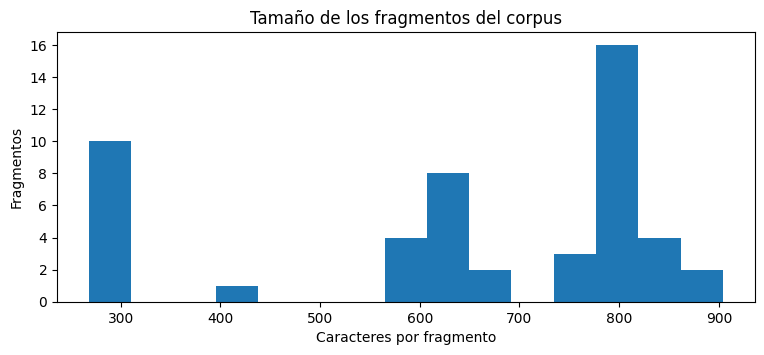

Mediana 720 caracteres; máximo 904 (límite 900).


In [4]:
import matplotlib.pyplot as plt
largos = [len(f) for d in docs for f in d.fragmentos]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(largos, bins=15)
ax.set_title("Tamaño de los fragmentos del corpus")
ax.set_xlabel("Caracteres por fragmento"); ax.set_ylabel("Fragmentos")
plt.show()
print(f"Mediana {pd.Series(largos).median():.0f} caracteres; máximo {max(largos)} (límite {TAMANO}).")

## Ejemplo de fragmento (con metadatos que se guardan en `rag.fragmentos`)

In [5]:
from pipeline.src.rag.indexar import filas
documentos, fragmentos = filas(docs)
ej = fragmentos[0]
print({k: v for k, v in ej.items() if k != "contenido"})
print(ej["contenido"][:600])

{'fragmento_id': '5d25a090-9f25-5893-9204-7cd0e6a02f34', 'documento_id': '2472d9de-639d-5b92-af58-0ed0890b49b0', 'orden': 0, 'metadata': {'fuente': 'api/_lib/tarifas_cea.csv', 'tipo': 'tarifa', 'caracteres': 597}}
Tarifa Beneficencia (beneficencia), periodo 2026-T3, importe de agua potable antes de alcantarillado, saneamiento e IVA, de 0 a 9 m³: 0 m³ = $49.77; 1 m³ = $75.67; 2 m³ = $88.45; 3 m³ = $101.51; 4 m³ = $114.89; 5 m³ = $128.59; 6 m³ = $142.58; 7 m³ = $156.88; 8 m³ = $171.51; 9 m³ = $193.85.

Tarifa Beneficencia (beneficencia), periodo 2026-T3, importe de agua potable antes de alcantarillado, saneamiento e IVA, de 10 a 19 m³: 10 m³ = $209.71; 11 m³ = $225.86; 12 m³ = $244.28; 13 m³ = $265.83; 14 m³ = $285.70; 15 m³ = $306.20; 16 m³ = $327.36; 17 m³ = $350.82; 18 m³ = $373.37; 19 m³ = $396.59.


## Control de alucinaciones (diseño de `api/_lib/rag.py`)

1. Si ninguna similitud supera el umbral, `evidencia=false` y **no se llama al LLM**.
2. El LLM recibe solo los fragmentos numerados y debe responder `SIN_EVIDENCIA` si no bastan.
3. La salida se valida con Pydantic y debe citar al menos un fragmento existente; si no, se responde de forma extractiva.

In [6]:
from api._lib.rag import UMBRAL_SIMILITUD, SIN_EVIDENCIA, responder

class EmbeddingFijo:            # solo para demostrar el flujo sin llaves: NO es una métrica
    def embeber(self, textos): return [[1.0] + [0.0] * 767 for _ in textos]

sin_fuentes = lambda v, k: [{"fragmento_id": "x", "documento_id": "y", "titulo": "otro tema", "contenido": "…", "similitud": 0.2}]
salida, detalle = responder("¿Quién ganó el mundial?", 5, EmbeddingFijo(), sin_fuentes, llm=None)
print(f"umbral = {UMBRAL_SIMILITUD}; evidencia = {salida.evidencia}; respuesta: {salida.respuesta}")

umbral = 0.6; evidencia = False; respuesta: No encontré información sobre eso en los documentos disponibles (tarifario CEA, reglas del recibo y documentación del proyecto).


## Preguntas de evaluación (T-16a)

Borrador en `docs/eval/rag_preguntas_borrador.csv`; **solo las validadas por una persona** entran a la métrica.

In [7]:
from pipeline.src.rag.evaluar import cargar_preguntas
todas = cargar_preguntas(incluir_sin_validar=True)
validadas = cargar_preguntas()
print(f"{len(todas)} preguntas en el borrador · {sum(not p['con_evidencia'] for p in todas)} sin evidencia esperada · {len(validadas)} validadas")

40 preguntas en el borrador · 7 sin evidencia esperada · 40 validadas


## Resultado: Recall@k, MRR y abstención (rag_eval)

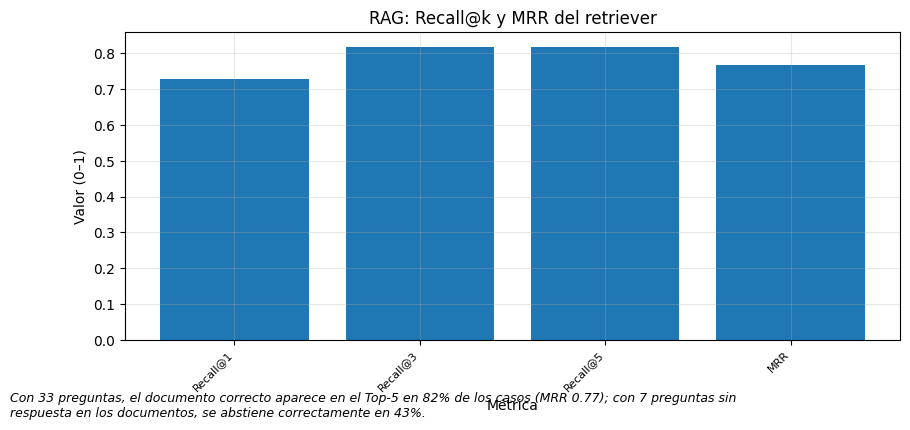

In [8]:
p = resultado("rag_eval", "recall_mrr")
if p:
    dibujar(p)
else:
    print("PENDIENTE: aún no se corre `python -m pipeline.src.rag.evaluar` (requiere el índice en rag.fragmentos y preguntas validadas).")

## Calibración del umbral de similitud

Con las mismas similitudes máximas de las preguntas validadas se barre el umbral de 0.30 a 0.90 y se elige el que
maximiza la exactitud balanceada. Como se calibra con las mismas preguntas, la estimación honesta es la de dejar una fuera.

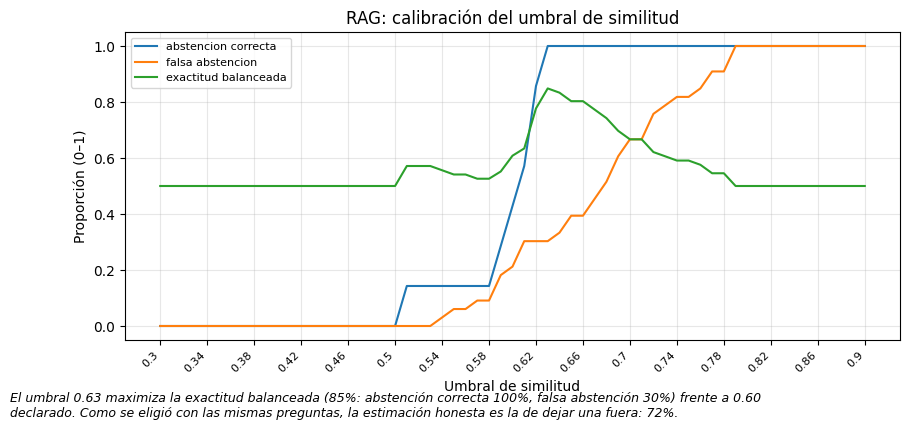

In [9]:
u = resultado("rag_eval", "umbral")
if u:
    dibujar(u)
else:
    print("PENDIENTE: la calibración sale de `python -m pipeline.src.rag.evaluar` con el índice cargado.")

## Conclusiones

In [10]:
print(f"1. El corpus tiene {len(docs)} documentos y {resumen['fragmentos'].sum()} fragmentos; cada fragmento guarda fuente, tipo y tamaño para citarlo.")
print(f"2. El umbral de evidencia ({UMBRAL_SIMILITUD}) hace que una pregunta fuera del corpus responda sin evidencia sin llamar al LLM.")
if p:
    print("3. " + p["conclusion"])
else:
    print(f"3. La métrica del retriever está pendiente: faltan el índice y la validación de {len(todas)} preguntas; no se reporta un número sin correrla.")
print("4. " + (u["conclusion"] if u else "La calibración del umbral está pendiente de correr el evaluador."))
print("5. La app muestra las fuentes de cada respuesta (título, fragmento y similitud) en la página Asistente IA.")

1. El corpus tiene 14 documentos y 50 fragmentos; cada fragmento guarda fuente, tipo y tamaño para citarlo.
2. El umbral de evidencia (0.6) hace que una pregunta fuera del corpus responda sin evidencia sin llamar al LLM.
3. Con 33 preguntas, el documento correcto aparece en el Top-5 en 82% de los casos (MRR 0.77); con 7 preguntas sin respuesta en los documentos, se abstiene correctamente en 43%.
4. El umbral 0.63 maximiza la exactitud balanceada (85%: abstención correcta 100%, falsa abstención 30%) frente a 0.60 declarado. Como se eligió con las mismas preguntas, la estimación honesta es la de dejar una fuera: 72%.
5. La app muestra las fuentes de cada respuesta (título, fragmento y similitud) en la página Asistente IA.
